# Evaluation of the generated reviews (Zero-Shot examples)

## Load Dataset

In [56]:
from pathlib import Path

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

In [57]:
import os
import json
import pandas as pd

dfs = []

json_dir = DATA_DIR / "zero-shot"

for file_name in os.listdir(str(json_dir)):
  if file_name.endswith(".json"):
    file_path = json_dir / file_name
    with open(file_path, "r", encoding="utf-8") as f:
      print(f"Loading '{file_name}'...")
      data = json.load(f)
      df = pd.DataFrame(data["reviews"])
      df["total_reviews"] = data["total_reviews"]
      dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

Loading 'mistral_latest_reviews.json'...
Loading 'codellama_latest_reviews.json'...
Loading 'llama3.1_latest_reviews.json'...
Loading 'qwen2.5-coder_32b_reviews.json'...


In [58]:
combined_df.sample(5)

,model,restaurant,category,ai_rating,human_rating,keywords,ai_review,human_review,word_count,total_reviews
399,mistral:latest,Diners Pavilion,General,2.6,1,"['plates', 'request', 'seen']",I recently visited Diners Pavilion for a casua...,worst service ever seen bug in food cold food ...,111,500
91,mistral:latest,Owm Nom Nom,General,2.1,1,"['sorry', 'oily', 'bland']","""Had dinner at Owm Nom Nom last night with my ...",painfully slow delivery exceedingly oily and b...,110,500
617,codellama:latest,La La Land - Bar & Kitchen,Dessert,1.5,2,"['ingredients', 'use', 'horrible']","""I recently had the pleasure of dining at La L...",they dont seem to use good quality ingredients...,61,500
1466,llama3.1:latest,Pista House,Indian,4.7,4,"['45', 'chicken', 'nice']",I'm a huge fan of Indian food and Pista House ...,ambiance 45 nice and clean place service 45 ni...,121,500
833,codellama:latest,13 Dhaba,General,2.7,1,"['kulcha', 'daal', 'raw']","""13 Dhaba is a gem of a restaurant that serves...",just ordered gobhi kulcha and daal makhani kul...,87,500


In [59]:
combined_df.rename(columns={"ai_review": "gen_review"}, inplace=True)

In [60]:
combined_df_deduplicated = combined_df.groupby(['category', 'keywords', 'model']).apply(lambda x: x.sample(n=1, random_state=42)).reset_index(drop=True)
print(f"Original DataFrame size: {len(combined_df)}")
print(f"Deduplicated DataFrame size: {len(combined_df_deduplicated)}")
combined_df = combined_df_deduplicated
print(combined_df.shape)

Original DataFrame size: 2000
Deduplicated DataFrame size: 200
(200, 10)


/tmp/ipython-input-2832734445.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df_deduplicated = combined_df.groupby(['category', 'keywords', 'model']).apply(lambda x: x.sample(n=1, random_state=42)).reset_index(drop=True)


In [61]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          200 non-null    object 
 1   restaurant     200 non-null    object 
 2   category       200 non-null    object 
 3   ai_rating      200 non-null    float64
 4   human_rating   200 non-null    int64  
 5   keywords       200 non-null    object 
 6   gen_review     200 non-null    object 
 7   human_review   200 non-null    object 
 8   word_count     200 non-null    int64  
 9   total_reviews  200 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 15.8+ KB


In [62]:
combined_df.model.unique()

array(['codellama:latest', 'llama3.1:latest', 'mistral:latest',
       'qwen2.5-coder:32b'], dtype=object)

In [63]:
combined_df.model.value_counts()

,count
model,
codellama:latest,50
llama3.1:latest,50
mistral:latest,50
qwen2.5-coder:32b,50


In [64]:
combined_df.restaurant.unique()

array(['Komatose - Holiday Inn Express & Suites', "Udipi's Upahar",
       'La La Land - Bar & Kitchen', 'SKYHY', 'Chinese Pavilion',
       'Labonel', 'Beyond Flavours', 'Cream Stone', 'eat.fit',
       "Dunkin' Donuts", "GD's", 'Olive Garden', 'Squeeze @ The Lime',
       '10 Downing Street', 'Mustang Terrace Lounge',
       "Sardarji's Chaats & More", '13 Dhaba', 'Al Saba Restaurant',
       'Shah Ghouse Hotel & Restaurant', 'Owm Nom Nom',
       "Zing's Northeast Kitchen", 'Diners Pavilion', 'PourHouse7',
       'Paradise', 'Dine O China', 'Banana Leaf Multicuisine Restaurant',
       'Faasos', 'Pista House', 'Royal Spicy Restaurant',
       'Hyderabadi Daawat', 'Behrouz Biryani', 'Biryanis And More',
       'Khaan Saab', 'KS Bakers', 'Flechazo', 'Frio Bistro',
       'The Glass Onion', "The Fisherman's Wharf",
       "AB's - Absolute Barbecues", 'T Grill'], dtype=object)

In [65]:
combined_df.category.unique()

array(['Bar', 'Chinese', 'Dessert', 'General', 'Indian', 'Italian',
       'Seafood', 'Steakhouse'], dtype=object)

### Clean Generated Review Text

In [66]:
combined_df.gen_review.sample(3).tolist()

["Visited Udipi's Upahar recently for a casual dinner with friends and I must say, it was an absolute delight! The restaurant has this cozy, inviting vibe that immediately makes you feel at home. The service was swift and friendly, but not intrusive – just the right balance.\n\nNow, onto the food! I tried their Bar Chicken and it was fantastic. Perfectly cooked, tender yet crispy, with a lovely spice blend that danced on your taste buds. The chutney they serve here is simply amazing, it's one of those homemade kinds that just lifts the whole dish to another level.\n\nMy friend ordered the Paneer Tik",
 '"Shah Ghouse Hotel & Restaurant is a great place to stay and eat if you\'re looking for authentic Pakistani cuisine. The food was delicious and made me feel like I was back home in Pakistan. The service was excellent, the staff were friendly and helpful. The atmosphere was warm and welcoming, with a nice garden outside that provided a lovely spot to relax after dinner. The prices were r

In [67]:
import re

def clean_generated_review(text: str) -> str:
    if not isinstance(text, str):
        return ""

    original = text


    if "<think>" in text and "</think>" not in text:
        return ""   # mark as empty so the row can later be filtered out


    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()


    meta_patterns = [
        r"^Here['’]s my attempt.*?:",      # Here’s my attempt...
        r"^Here'?s my attempt at writing .*?review:\s*",
        r"^Here['’]s my review.*?:",       # Here’s my review...
        r"^Here'?s my honest review:\s*",
        r"^Here is my review.*?:",
        r"^\"Here.*?\":",                  # "Here is..."
        r"^Title:.*?\n",                   # Title: ... lines
        r"^Rating:\s*\d.*?\n",             # Rating: 5 etc.
        r"^Okay.*?\n",                     # LLM thinking noise
        r"^Hmm.*?\n",
        r"\*\*\d+(\.\d+)?\/5 stars\*\*\s*",
        r"\*\*.*?\*\*\s*",  # bold titles
        r"\"{2,}",  # repeated quotes
    ]


    for pat in meta_patterns:
        text = re.sub(pat, "", text, flags=re.IGNORECASE | re.DOTALL).strip()


    # Remove extra quotes around the review
    text = text.strip(' "\'')

    # Enforce length constraints (20–500 words)
    word_count = len(text.split())
    if word_count < 20 or word_count > 500:
        return ""


    # If the review contains markdown fences or code-like formatting, remove them
    text = re.sub(r"^```.*?```", "", text, flags=re.DOTALL).strip()

    # Clean repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # keep alphanumeric
    # text = re.sub(r'[^a-z0-9\s]', '', text)

    return text.lower()



def clean_dataset(df: pd.DataFrame, review_column: str = "gen_review"):

    df = df.copy()

    # Clean review text
    df[review_column] = df[review_column].apply(clean_generated_review)

    # Remove rows where the generated review is empty or only whitespace
    df = df[df[review_column].str.len() > 10].reset_index(drop=True)

    return df

In [68]:
combined_df = clean_dataset(combined_df)

In [73]:
combined_df.gen_review.sample(3).tolist()

['visited frio bistro last night for a special dinner, and let me tell you, it was worth every bite. the ambiance is cozy yet sophisticated, perfect for a romantic evening or just a night out with friends. i started with the minestrone soup, which was hearty and full of flavor, the perfect way to start a meal. for my main course, i had the risotto al nero di seppia, and it was incredibly creamy with a rich squid ink flavor that really set it apart. the service was impeccable; our waiter, marco, made us feel right at home',
 "wow, i'm absolutely loving my time at komatose - holiday inn express & suites! the bar food is top-notch and the service is exceptional. our server was friendly and attentive throughout our meal, and the atmosphere was calm and soothing. we had a great time chatting with other travelers and enjoying some delicious cocktails. overall, i would highly recommend this restaurant to anyone looking for a unique dining experience.",
 'visited banana leaf multicuisine resta

# Compute evaluation metrics for human vs. generated reviews.

In [70]:
!pip -q install textstat

In [71]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from textstat import flesch_reading_ease
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import pipeline

# transformers sentiment model
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def compute_metrics(df):
    """
    Compute automatic evaluation metrics for human vs. generated reviews.
    Includes:
      - TF-IDF cosine similarity
      - BLEU score
      - Readability (Flesch Reading Ease)
      - Transformer-based Sentiment Analysis

    Expected columns:
        ['model', 'restaurant', 'category', 'rating', 'keywords',
         'gen_review', 'word_count', 'total_reviews', 'human_review']

    Returns:
        results_df, summary_dict
    """

    df = df.copy()

    # drop missing reviews
    df.dropna(subset=["gen_review", "human_review"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 1. Cosine Similarity (TF-IDF)
    tfidf = TfidfVectorizer(stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["human_review"].tolist() + df["gen_review"].tolist())
    human_vecs = tfidf_matrix[:len(df)]
    gen_vecs = tfidf_matrix[len(df):]
    cosine_scores = cosine_similarity(human_vecs, gen_vecs).diagonal()

    # 2. BLEU Score
    smoothie = SmoothingFunction().method1
    bleu_scores = []
    for h, g in zip(df["human_review"], df["gen_review"]):
        bleu = sentence_bleu([h.split()], g.split(), smoothing_function=smoothie)
        bleu_scores.append(bleu)

    # 3. Readability (Flesch Reading Ease)
    readability_gen = [flesch_reading_ease(g) for g in df["gen_review"]]
    readability_human = [flesch_reading_ease(h) for h in df["human_review"]]
    readability_diff = np.array(readability_gen) - np.array(readability_human)

    # 4. Transformer-based Sentiment Analysis
    def get_sentiment_scores(texts):
        """Get sentiment polarity (1 for positive, -1 for negative) and confidence score"""
        results = sentiment_analyzer(texts, truncation=True)
        sentiments = []
        for r in results:
            polarity = 1 if r["label"] == "POSITIVE" else -1
            score = polarity * r["score"]
            sentiments.append(score)
        return sentiments

    sentiment_gen = get_sentiment_scores(df["gen_review"].tolist())
    sentiment_human = get_sentiment_scores(df["human_review"].tolist())
    sentiment_diff = np.array(sentiment_gen) - np.array(sentiment_human)

    # results
    df["cosine_sim"] = cosine_scores
    df["bleu"] = bleu_scores
    df["readability_gen"] = readability_gen
    df["readability_human"] = readability_human
    df["readability_diff"] = readability_diff
    df["sentiment_gen"] = sentiment_gen
    df["sentiment_human"] = sentiment_human
    df["sentiment_diff"] = sentiment_diff

    # summary
    summary = {
        "avg_cosine_sim": np.mean(cosine_scores),
        "avg_bleu": np.mean(bleu_scores),
        "avg_readability_gen": np.mean(readability_gen),
        "avg_readability_human": np.mean(readability_human),
        "avg_readability_diff": np.mean(readability_diff),
        "avg_sentiment_gen": np.mean(sentiment_gen),
        "avg_sentiment_human": np.mean(sentiment_human),
        "avg_sentiment_diff": np.mean(sentiment_diff),
        "n_reviews": len(df)
    }

    print("\n=== Automatic Evaluation Summary ===")
    for k, v in summary.items():
        print(f"{k:25s}: {v:.4f}" if isinstance(v, (int, float)) else f"{k:25s}: {v}")

    return df, summary


Device set to use cpu


In [72]:
results_df, summary = compute_metrics(combined_df)
results_df.sample(3)


=== Automatic Evaluation Summary ===
avg_cosine_sim           : 0.1096
avg_bleu                 : 0.0064
avg_readability_gen      : 61.7133
avg_readability_human    : 30.1399
avg_readability_diff     : 31.5734
avg_sentiment_gen        : 0.8293
avg_sentiment_human      : 0.1636
avg_sentiment_diff       : 0.6656
n_reviews                : 200.0000


,model,restaurant,category,ai_rating,human_rating,keywords,gen_review,human_review,word_count,total_reviews,cosine_sim,bleu,readability_gen,readability_human,readability_diff,sentiment_gen,sentiment_human,sentiment_diff
138,mistral:latest,Hyderabadi Daawat,Indian,4.5,4,"['best', 'flavoured', 'dum']",visited hyderabadi daawat last weekend for a f...,chicken dum biryani is so tasty zomato is prov...,81,500,0.057915,0.006890,48.890000,75.686429,-26.796429,0.999862,0.999754,0.000108
44,codellama:latest,GD's,General,2.8,4,"['burgers', 'juicy', 'thank']",just had a meal at gd's and it was an incredib...,burgers were very good and the hotdog was also...,53,500,0.130246,0.012988,65.688137,62.107391,3.580745,0.999883,0.999778,0.000105
27,qwen2.5-coder:32b,Beyond Flavours,Dessert,2.1,5,"['complimentary', 'recently', 'does']",i recently visited beyond flavours for a frien...,we had our farewell feast here recently enjoye...,67,500,0.133470,0.004945,58.514347,40.030909,18.483438,0.999842,0.999876,-0.000034


# Interpret the evaluation summary

In [74]:
from scipy.stats import pearsonr

def interpret_results(results_df, summary):
    """
    Interpret the automatic evaluation summary and compare
    metrics with existing columns (e.g., rating, category).
    """

    print("=== INTERPRETATION OF AUTOMATIC EVALUATION RESULTS ===\n")

    # =====================================================
    # PART 1: QUANTITATIVE INTERPRETATION
    # =====================================================

    # 1️⃣ Cosine Similarity
    if summary["avg_cosine_sim"] < 0.2:
        print(f"- 🔸 Cosine similarity ({summary['avg_cosine_sim']:.3f}) is low, "
              "suggesting the generated reviews use significantly different wording "
              "than human reviews (less lexical overlap).")
    else:
        print(f"- ✅ Cosine similarity ({summary['avg_cosine_sim']:.3f}) is moderate to high, "
              "indicating generated text linguistically resembles human writing.")

    # 2️⃣ BLEU Score
    if summary["avg_bleu"] < 0.05:
        print(f"- ⚠️ BLEU score ({summary['avg_bleu']:.3f}) is very low — the generated reviews "
              "do not closely match human phrasing. This is normal for creative text like reviews.")
    else:
        print(f"- ✅ BLEU score ({summary['avg_bleu']:.3f}) indicates higher n-gram overlap.")

    # 3️⃣ Readability
    diff_read = summary["avg_readability_diff"]
    if diff_read > 5:
        print(f"- 🧠 Generated reviews are noticeably easier to read (avg diff {diff_read:.2f}).")
    elif diff_read < -5:
        print(f"- 🧩 Generated reviews are harder to read (avg diff {diff_read:.2f}).")
    else:
        print(f"- ⚖️ Readability difference ({diff_read:.2f}) is small — models produce text "
              "of comparable complexity to humans.")

    # 4️⃣ Sentiment
    sent_diff = summary["avg_sentiment_diff"]
    if sent_diff < -0.05:
        print(f"- 😕 Generated reviews are slightly *more negative* on average "
              f"({sent_diff:.3f}) than human reviews.")
    elif sent_diff > 0.05:
        print(f"- 😀 Generated reviews are slightly *more positive* on average "
              f"({sent_diff:.3f}) than human reviews.")
    else:
        print(f"- ⚖️ Sentiment difference ({sent_diff:.3f}) is small — emotional tone is similar.")

    print(f"- 📊 Total reviews evaluated: {int(summary['n_reviews'])}\n")

    # =====================================================
    # PART 2: CONTEXTUAL COMPARISON WITH EXISTING COLUMNS
    # =====================================================
    print("=== CONTEXTUAL COMPARISONS ===\n")

    if "rating" in results_df.columns:
        try:
            corr_sent_rating, _ = pearsonr(results_df["rating"], results_df["sentiment_gen"])
            print(f"- 📈 Correlation between model sentiment and star rating: {corr_sent_rating:.3f}")
            if corr_sent_rating > 0.3:
                print("  → Higher star ratings correspond to more positive generated sentiment.")
            elif corr_sent_rating < -0.3:
                print("  → Unexpectedly, higher ratings correspond to more negative sentiment.")
            else:
                print("  → Weak or no relationship between generated sentiment and rating.")
        except Exception:
            print("- ⚠️ Could not compute correlation (missing or invalid values).")

    # Check per-category averages
    if "category" in results_df.columns:
        cat_stats = results_df.groupby("category")[["cosine_sim", "bleu", "sentiment_gen"]].mean().round(3)
        print("\n=== Average Metrics per Category ===")
        print(cat_stats)
        print()

    print("✅ Interpretation complete.")


In [75]:
interpret_results(results_df, summary)

=== INTERPRETATION OF AUTOMATIC EVALUATION RESULTS ===

- 🔸 Cosine similarity (0.110) is low, suggesting the generated reviews use significantly different wording than human reviews (less lexical overlap).
- ⚠️ BLEU score (0.006) is very low — the generated reviews do not closely match human phrasing. This is normal for creative text like reviews.
- 🧠 Generated reviews are noticeably easier to read (avg diff 31.57).
- 😀 Generated reviews are slightly *more positive* on average (0.666) than human reviews.
- 📊 Total reviews evaluated: 200

=== CONTEXTUAL COMPARISONS ===


=== Average Metrics per Category ===
            cosine_sim   bleu  sentiment_gen
category                                    
Bar              0.099  0.008          1.000
Chinese          0.145  0.008          0.906
Dessert          0.106  0.006          0.875
General          0.108  0.007          0.742
Indian           0.130  0.006          0.999
Italian          0.094  0.006          1.000
Seafood          0.089  0.

# Semantic and Embedding-Based Similarity

In [76]:
from sentence_transformers import SentenceTransformer, util
import torch

# Load a MPNet model (for similarity)
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def compute_similarity(text1: str, text2: str) -> float:
    """
    Computes BERT-based cosine similarity between two texts.
    Returns a float in the range [-1, 1].
    """
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0.0

    embeddings = model.encode([text1, text2], convert_to_tensor=True)
    sim = util.pytorch_cos_sim(embeddings[0], embeddings[1]).item()
    return float(sim)


def add_semantic_similarity(df: pd.DataFrame,
                            human_col: str = "human_review",
                            gen_col: str = "gen_review") -> pd.DataFrame:
    """
    Adds a 'semantic_similarity' column to the dataset using BERT-based embeddings.
    """
    df = df.copy()
    similarities = []

    for human, gen in zip(df[human_col], df[gen_col]):
        score = compute_similarity(human, gen)
        similarities.append(score)

    df["semantic_similarity"] = similarities
    return df


In [77]:
results_df = add_semantic_similarity(results_df)
print("Average semantic similarity:", results_df["semantic_similarity"].mean())

Average semantic similarity: 0.5277125268056989


## Visualize the Embeddings

In [78]:
from umap import UMAP

# Reduce dimensionality for visualization

human_embeddings = model.encode(results_df["human_review"].tolist(), convert_to_tensor=True)
gen_embeddings = model.encode(results_df["gen_review"].tolist(), convert_to_tensor=True)

umap_model = UMAP(n_components=2, random_state=42)
umap_embed_human = umap_model.fit_transform(human_embeddings.cpu().numpy())
umap_embed_gen = umap_model.fit_transform(gen_embeddings.cpu().numpy())

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


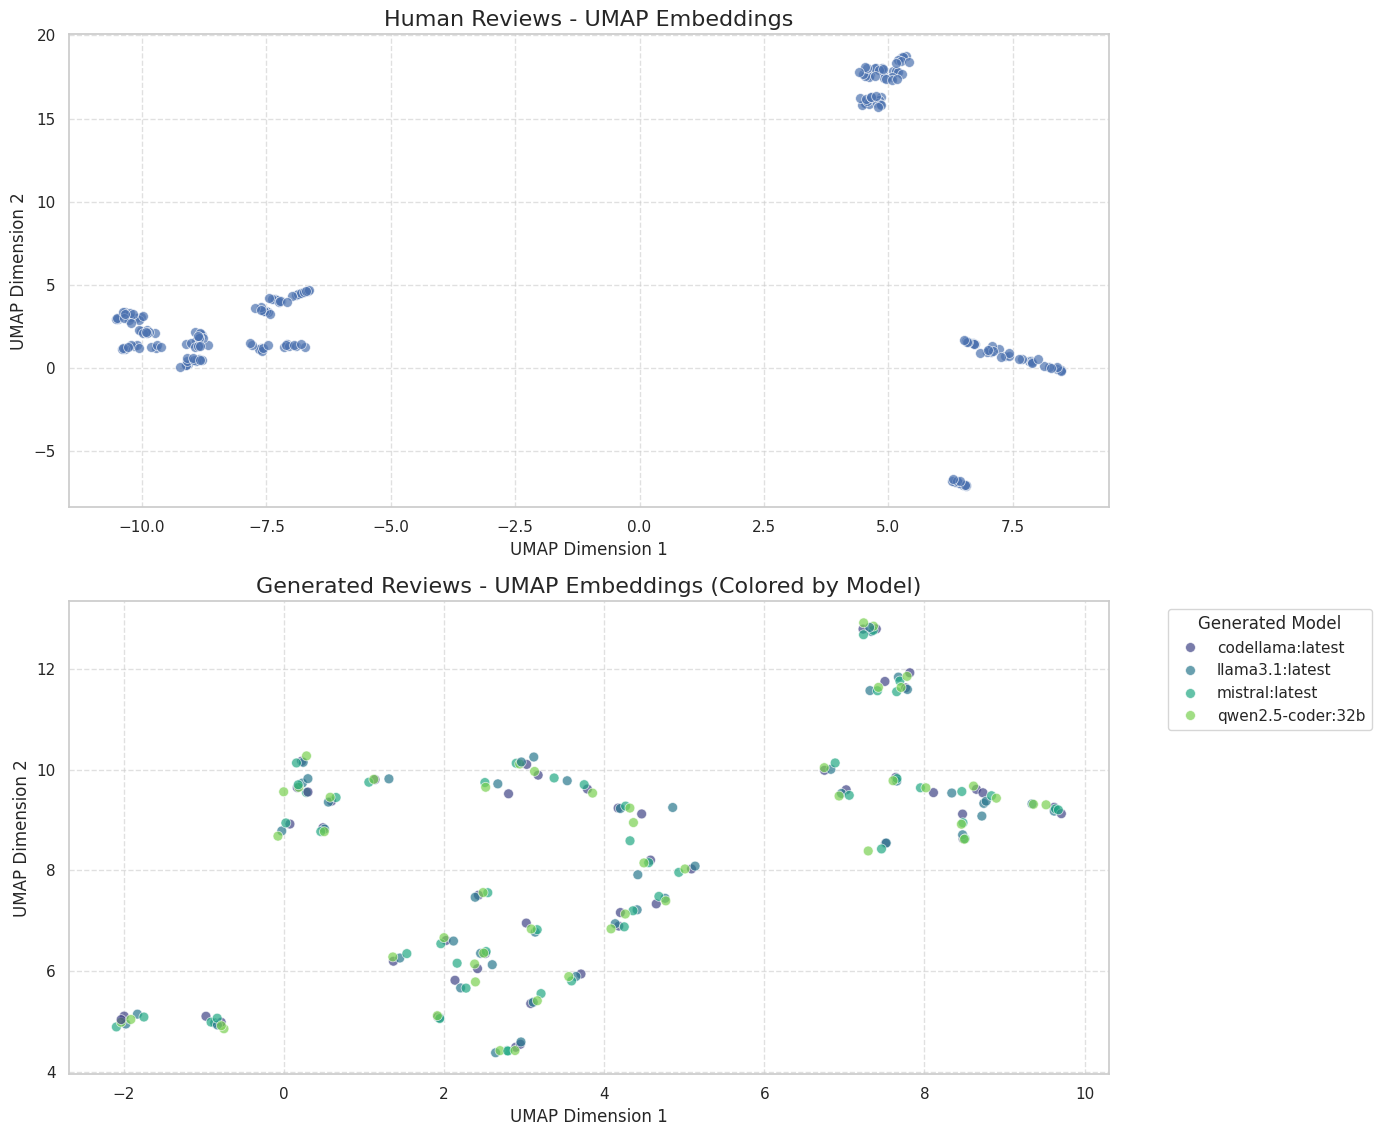

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 12))

# Plot for Human Reviews
plt.subplot(2, 1, 1)
sns.scatterplot(
    x=umap_embed_human[:, 0],
    y=umap_embed_human[:, 1],
    s=50,
    alpha=0.7,
    edgecolor='w',
    legend='full'
)
plt.title("Human Reviews - UMAP Embeddings", fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
# plt.legend(title="Associated Restaurant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)


# Plot for Generated Reviews
plt.subplot(2, 1, 2)
sns.scatterplot(
    x=umap_embed_gen[:, 0],
    y=umap_embed_gen[:, 1],
    hue=results_df['model'], # Color by the generated model
    palette='viridis',
    s=50,
    alpha=0.7,
    edgecolor='w',
    legend='full'
)
plt.title("Generated Reviews - UMAP Embeddings (Colored by Model)", fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(title="Generated Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Style Embedding Similarity

In [89]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

style_model = AutoModel.from_pretrained("AnnaWegmann/Style-Embedding")
tokenizer = AutoTokenizer.from_pretrained("AnnaWegmann/Style-Embedding")

def get_style_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        emb = style_model(**inputs).last_hidden_state.mean(dim=1)
    return emb.squeeze().numpy()

results_df["style_human"] = results_df["human_review"].apply(get_style_embedding)
results_df["style_gen"] = results_df["gen_review"].apply(get_style_embedding)
results_df["style_sim"] = results_df.apply(lambda x: cosine_similarity(
    [x["style_human"]], [x["style_gen"]])[0][0], axis=1)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [90]:
print("Average style similarity:", results_df["style_sim"].mean())

Average style similarity: 0.70820504


# Per-Restaurant Aggregation

In [91]:
restaurant_summary = (
    results_df.groupby("restaurant")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean"
      })
)
print(restaurant_summary.head())

                                     cosine_sim  semantic_similarity  \
restaurant                                                             
10 Downing Street                      0.045285             0.413910   
13 Dhaba                               0.094724             0.492684   
AB's - Absolute Barbecues              0.116963             0.519059   
Al Saba Restaurant                     0.082372             0.315433   
Banana Leaf Multicuisine Restaurant    0.238202             0.697871   

                                     sentiment_diff  
restaurant                                           
10 Downing Street                         -0.001002  
13 Dhaba                                   0.727736  
AB's - Absolute Barbecues                 -0.000332  
Al Saba Restaurant                         1.995192  
Banana Leaf Multicuisine Restaurant        0.000185  


# Per-Model Aggregation

In [92]:
model_summary = (
    results_df.groupby("model")
      .agg({
          "cosine_sim": "mean",
          "semantic_similarity": "mean",
          "sentiment_diff": "mean",
          "style_sim": "mean"
      })
)
print(model_summary.head())

                   cosine_sim  semantic_similarity  sentiment_diff  style_sim
model                                                                        
codellama:latest     0.089780             0.515351        0.676229   0.733847
llama3.1:latest      0.108589             0.537465        0.593660   0.710717
mistral:latest       0.105845             0.530832        0.716117   0.696697
qwen2.5-coder:32b    0.134035             0.527202        0.676572   0.691559


## Aggregate similarities by restaurant to detect model-specific biases.

In [93]:
restaurant_model_summary = (
    results_df.groupby(["restaurant", "model"])
    .agg({
        "cosine_sim": "mean",
        "semantic_similarity": "mean",
        "style_sim": "mean",
        "sentiment_diff": "mean"
    })
)

print(restaurant_model_summary.head(10))

                                             cosine_sim  semantic_similarity  \
restaurant                model                                                
10 Downing Street         codellama:latest     0.010425             0.366302   
                          llama3.1:latest      0.026158             0.353798   
                          mistral:latest       0.087303             0.472022   
                          qwen2.5-coder:32b    0.057256             0.463516   
13 Dhaba                  codellama:latest     0.098766             0.511355   
                          llama3.1:latest      0.102259             0.501944   
                          mistral:latest       0.070678             0.474037   
                          qwen2.5-coder:32b    0.107194             0.483400   
AB's - Absolute Barbecues codellama:latest     0.130073             0.471025   
                          llama3.1:latest      0.103743             0.633834   

                                       

# LLM-based Content Detection

In [95]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

# Load detector model and tokenizer
detector_name = "roberta-base-openai-detector"
tokenizer = AutoTokenizer.from_pretrained(detector_name)
model = AutoModelForSequenceClassification.from_pretrained(detector_name)

Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [96]:
def detect_ai_generated(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = softmax(logits.numpy()[0])
    # Model output: index 0 = real, index 1 = fake (AI-generated)
    return {"real_prob": probs[0], "fake_prob": probs[1]}

### Detect AI Generated Text on Generated Reviews

In [97]:
results_df["detector_result_gen"] = results_df["gen_review"].apply(detect_ai_generated)
results_df["gen_real_prob"] = results_df["detector_result_gen"].apply(lambda x: x["real_prob"])
results_df["gen_fake_prob"] = results_df["detector_result_gen"].apply(lambda x: x["fake_prob"])

print(results_df[["gen_review", "gen_real_prob", "gen_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_gen = results_df["gen_fake_prob"].mean()
print(f"Average AI-detection probability (fake-generated): {mean_fake_prob_gen:.3f}")

                                          gen_review  gen_real_prob  \
0  wow, i'm absolutely loving my time at komatose...       0.980878   
1  i stopped by komatose at the holiday inn expre...       0.000219   
2  had a wonderful evening at komatose, the bar i...       0.000273   
3  i recently had a chance to stop by komatose at...       0.054133   
4  wow, i recently discovered udipi's upahar, and...       0.929302   

   gen_fake_prob  
0       0.019122  
1       0.999781  
2       0.999727  
3       0.945867  
4       0.070698  
Average AI-detection probability (fake-generated): 0.829


### Detect AI Generated Text on Human Reviews

In [98]:
results_df["detector_result_human"] = results_df["human_review"].apply(detect_ai_generated)
results_df["human_real_prob"] = results_df["detector_result_human"].apply(lambda x: x["real_prob"])
results_df["human_fake_prob"] = results_df["detector_result_human"].apply(lambda x: x["fake_prob"])

print(results_df[["human_review", "human_real_prob", "human_fake_prob"]].head())

# compute mean fake probability
mean_fake_prob_human = results_df["human_fake_prob"].mean()
print(f"Average AI-detection probability (fake-human): {mean_fake_prob_human:.3f}")

                                        human_review  human_real_prob  \
0  the things which impressed me was the the cock...         0.008771   
1  the things which impressed me was the the cock...         0.008771   
2  the things which impressed me was the the cock...         0.008771   
3  the things which impressed me was the the cock...         0.008771   
4  ambience is okay but the food is good regular ...         0.333160   

   human_fake_prob  
0         0.991228  
1         0.991228  
2         0.991228  
3         0.991228  
4         0.666840  
Average AI-detection probability (fake-human): 0.919


# Per-Model Real/False Probability

In [99]:
model_prob = results_df.groupby("model").agg({"gen_fake_prob": "mean", "gen_real_prob": "mean"})
print(model_prob)

                   gen_fake_prob  gen_real_prob
model                                          
codellama:latest        0.512902       0.487098
llama3.1:latest         0.891114       0.108886
mistral:latest          0.967847       0.032153
qwen2.5-coder:32b       0.945777       0.054223


### Top 10 generated reviews classified as real

In [102]:
gen_prob_reviews = results_df[results_df['gen_real_prob'] > results_df['gen_fake_prob']][['model', 'gen_review', 'gen_real_prob',
                                                                                           'gen_fake_prob']]
gen_prob_reviews.sort_values(by='gen_real_prob', ascending=False).head(10)

,model,gen_review,gen_real_prob,gen_fake_prob
28,codellama:latest,i recently stumbled upon cream stone while bro...,0.999818,0.000182
8,codellama:latest,la la land - bar & kitchen is a hidden gem in ...,0.999807,0.000193
192,codellama:latest,just had a visit to absolute barbecues (ab's) ...,0.999782,0.000218
176,codellama:latest,i recently had the pleasure of dining at the g...,0.999578,0.000422
180,codellama:latest,i recently had the pleasure of dining at frio ...,0.999034,0.000966
48,codellama:latest,i recently visited olive garden with my family...,0.998885,0.001115
68,codellama:latest,i recently visited sardarji's chaats & more wi...,0.997917,0.002082
97,llama3.1:latest,i'm a big fan of the diners pavilion and i've ...,0.985184,0.014816
112,codellama:latest,owm nom nom is a restaurant that serves genera...,0.984976,0.015024
0,codellama:latest,"wow, i'm absolutely loving my time at komatose...",0.980878,0.019122


### Top 10 human reviews classified as fake

In [105]:
human_prob_reviews = results_df[results_df['human_fake_prob'] > results_df['human_real_prob']][['model', 'human_review', 'human_real_prob',
                                                                                           'human_fake_prob']]
human_prob_reviews.sort_values(by='human_fake_prob', ascending=False).head(10)

,model,human_review,human_real_prob,human_fake_prob
19,qwen2.5-coder:32b,i was told by one of my colleague about this p...,0.000173,0.999827
18,mistral:latest,i was told by one of my colleague about this p...,0.000173,0.999827
17,llama3.1:latest,i was told by one of my colleague about this p...,0.000173,0.999827
16,codellama:latest,i was told by one of my colleague about this p...,0.000173,0.999827
151,qwen2.5-coder:32b,having heard a lot about this place specially ...,0.000179,0.999821
150,mistral:latest,having heard a lot about this place specially ...,0.000179,0.999821
149,llama3.1:latest,having heard a lot about this place specially ...,0.000179,0.999821
148,codellama:latest,having heard a lot about this place specially ...,0.000179,0.999821
84,codellama:latest,second time being here its really beyond imagi...,0.000195,0.999805
85,llama3.1:latest,second time being here its really beyond imagi...,0.000195,0.999805


# Visualize The Results

## Model Performance Comparison

Create bar charts to compare `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models.


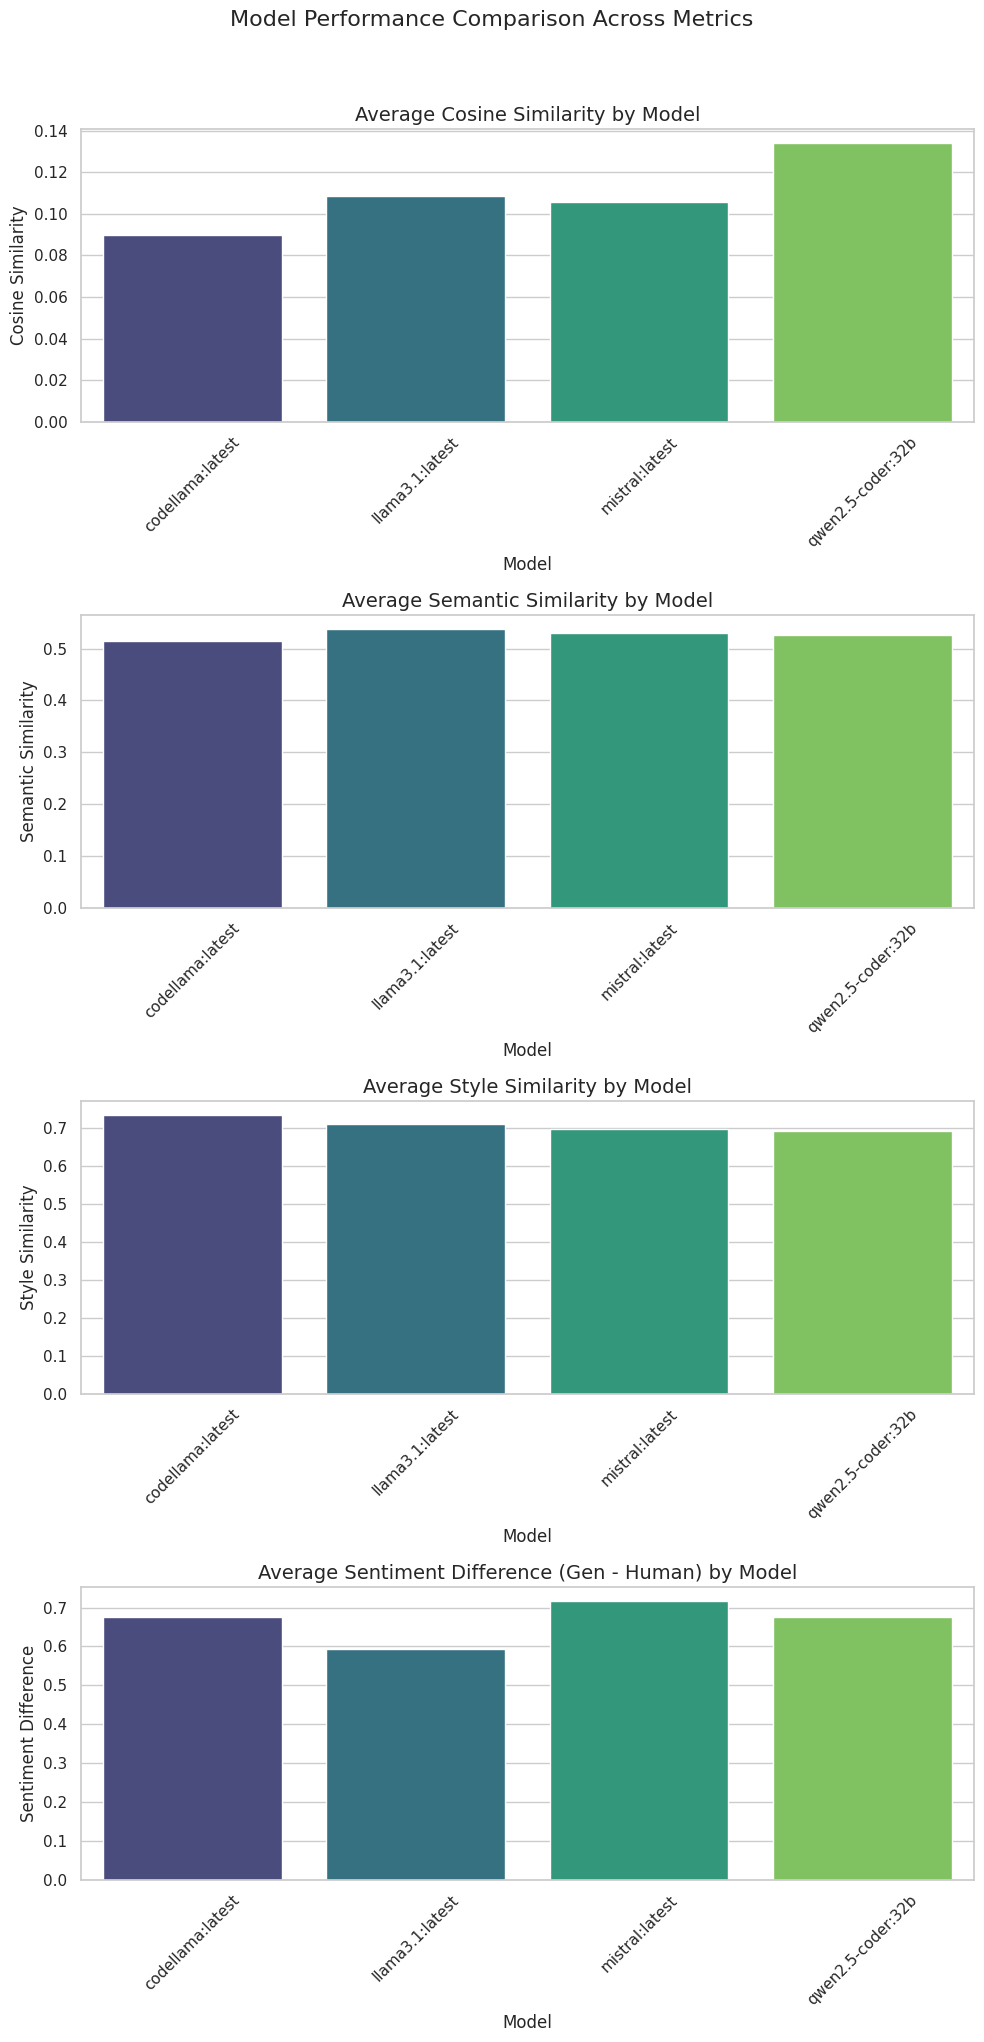

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Define the metrics to plot
metrics = ['cosine_sim', 'semantic_similarity', 'style_sim', 'sentiment_diff']
titles = {
    'cosine_sim': 'Average Cosine Similarity by Model',
    'semantic_similarity': 'Average Semantic Similarity by Model',
    'style_sim': 'Average Style Similarity by Model',
    'sentiment_diff': 'Average Sentiment Difference (Gen - Human) by Model'
}
ylabels = {
    'cosine_sim': 'Cosine Similarity',
    'semantic_similarity': 'Semantic Similarity',
    'style_sim': 'Style Similarity',
    'sentiment_diff': 'Sentiment Difference'
}

# Create subplots for each metric
fig, axes = plt.subplots(len(metrics), 1, figsize=(10, 5 * len(metrics)))
fig.suptitle('Model Performance Comparison Across Metrics', fontsize=16, y=1.02)

for i, metric in enumerate(metrics):
    sns.barplot(x=model_summary.index, y=model_summary[metric], hue=model_summary.index, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(titles[metric], fontsize=14)
    axes[i].set_xlabel('Model', fontsize=12)
    axes[i].set_ylabel(ylabels[metric], fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The bar charts above visualize the average performance of each language model across several key metrics:

- **Average Cosine Similarity**: Measures the lexical overlap between generated and human reviews. A higher value indicates more similar wording.
- **Average Semantic Similarity**: Assesses the underlying meaning similarity between generated and human reviews, using BERT-based embeddings. Higher values suggest the generated reviews capture the essence of human reviews better.
- **Average Style Similarity**: Compares the stylistic resemblance between generated and human reviews. Higher values imply the generated text mimics the writing style of human reviews more closely.
- **Average Sentiment Difference (Gen - Human)**: Indicates the average difference in sentiment scores between generated and human reviews. Positive values mean generated reviews are more positive, while negative values mean they are more negative than human reviews.

### Average AI-Detection Probability by Model
Create a bar chart to show the average AI-detection probability (`gen_fake_prob`) for each model.


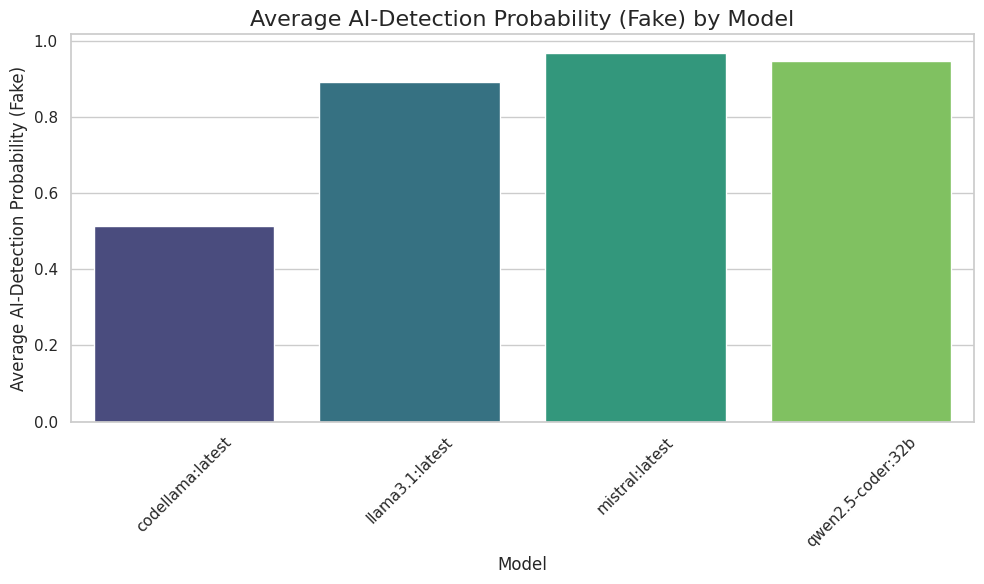

In [107]:
plt.figure(figsize=(10, 6))
sns.barplot(x=model_prob.index, y=model_prob['gen_fake_prob'], hue=model_prob.index, palette='viridis', legend=False)
plt.title('Average AI-Detection Probability (Fake) by Model', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Average AI-Detection Probability (Fake)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Similarity Metrics
Create histograms to show the distribution of `cosine_sim` and `semantic_similarity`.

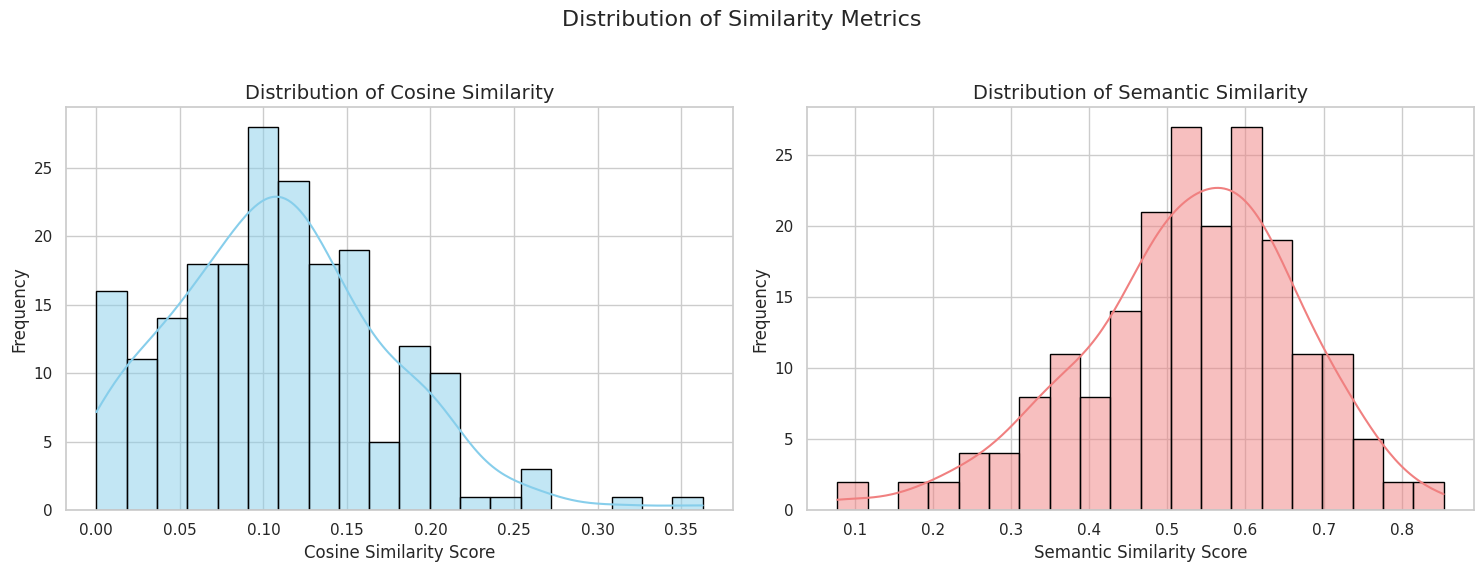

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribution of Similarity Metrics', fontsize=16)

# Histogram for Cosine Similarity
sns.histplot(results_df['cosine_sim'], bins=20, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Cosine Similarity', fontsize=14)
axes[0].set_xlabel('Cosine Similarity Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Histogram for Semantic Similarity
sns.histplot(results_df['semantic_similarity'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Semantic Similarity', fontsize=14)
axes[1].set_xlabel('Semantic Similarity Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Compare Readability of Generated vs. Human Reviews
Create box plots to compare `readability_gen` and `readability_human` from `results_df`.

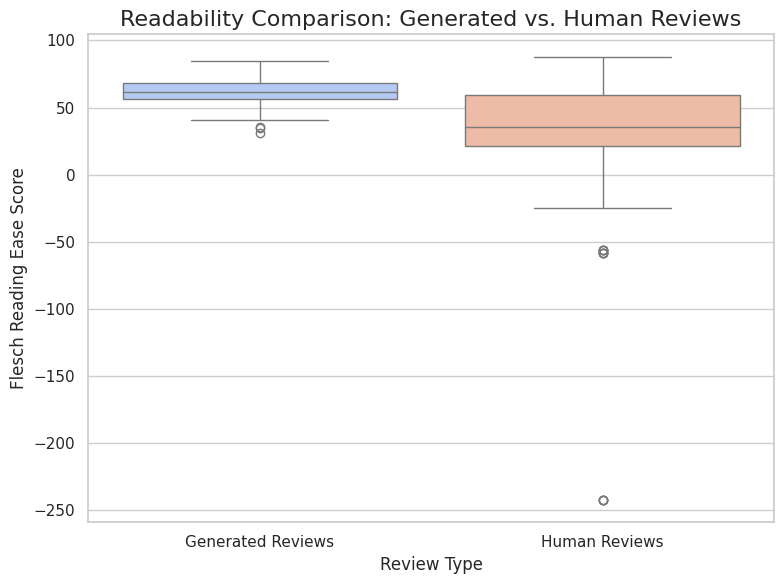

In [109]:
# Prepare data for box plot
readability_data = results_df[['readability_gen', 'readability_human']].melt(var_name='Review Type', value_name='Flesch Reading Ease Score')
readability_data['Review Type'] = readability_data['Review Type'].replace({
    'readability_gen': 'Generated Reviews',
    'readability_human': 'Human Reviews'
})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Review Type', y='Flesch Reading Ease Score', data=readability_data, hue='Review Type', palette='coolwarm', legend=False)
plt.title('Readability Comparison: Generated vs. Human Reviews', fontsize=16)
plt.xlabel('Review Type', fontsize=12)
plt.ylabel('Flesch Reading Ease Score', fontsize=12)
plt.tight_layout()
plt.show()

### Compare AI-Detection Probability for Generated vs. Human Reviews
Create histograms to compare `gen_fake_prob` and `human_fake_prob` from `results_df`.

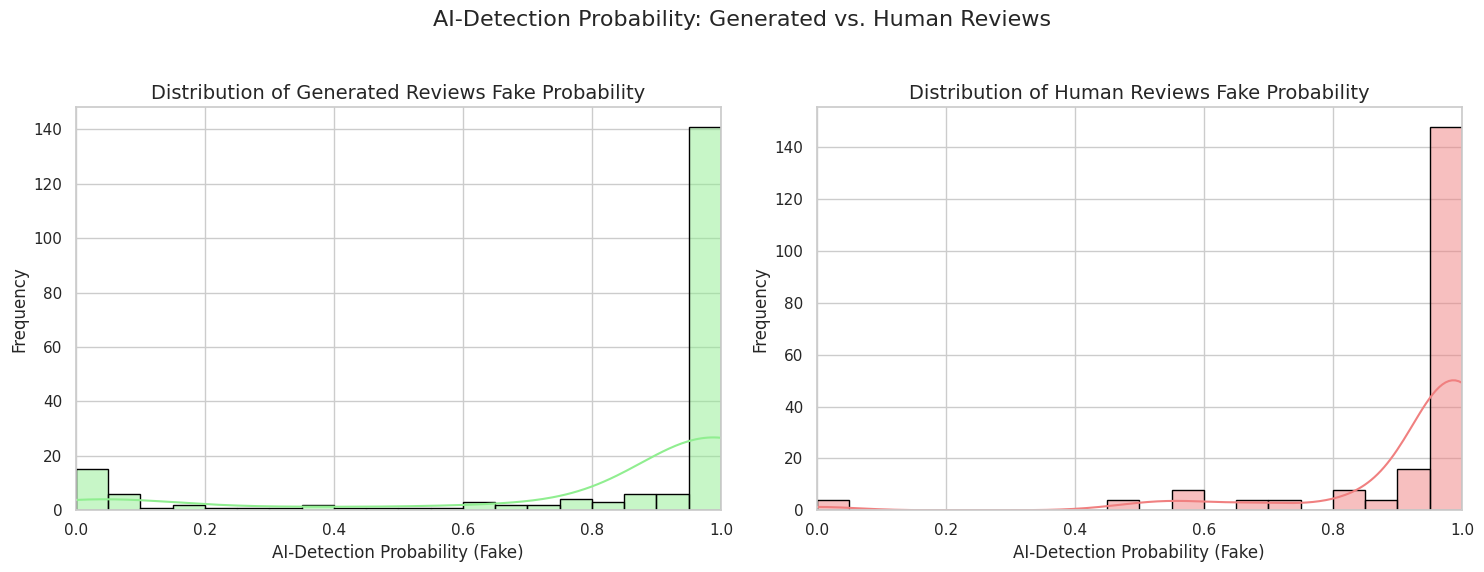

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AI-Detection Probability: Generated vs. Human Reviews', fontsize=16)

# Histogram for Generated Fake Probability
sns.histplot(results_df['gen_fake_prob'], bins=20, kde=True, ax=axes[0], color='lightgreen', edgecolor='black')
axes[0].set_title('Distribution of Generated Reviews Fake Probability', fontsize=14)
axes[0].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_xlim(0, 1) # Probability range

# Histogram for Human Fake Probability
sns.histplot(results_df['human_fake_prob'], bins=20, kde=True, ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Human Reviews Fake Probability', fontsize=14)
axes[1].set_xlabel('AI-Detection Probability (Fake)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_xlim(0, 1) # Probability range

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Model Performance across Metrics:**
    *   Bar charts were generated to compare average `cosine_sim`, `semantic_similarity`, `style_sim`, and `sentiment_diff` across different models, illustrating their varied performance in lexical, semantic, and stylistic similarity, as well as sentiment alignment with human reviews.
*   **Average AI-Detection Probability:**
    *   A bar chart was created showing the average AI-detection probability (`gen_fake_prob`) for each model, indicating how likely generated reviews from each model are to be flagged as AI-generated.
*   **Distribution of Similarity Metrics:**
    *   Histograms revealed the distribution of `cosine_sim` and `semantic_similarity` across all generated reviews, providing insights into the overall range and frequency of these similarity scores.
*   **Correlation between Rating and Generated Sentiment:**
    *   A scatter plot with a regression line visualized the relationship between the `rating` of the original review and the `sentiment_gen` of the generated review, suggesting how well models align sentiment with star ratings.
*   **Readability Comparison:**
    *   Box plots compared the Flesch Reading Ease scores for `readability_gen` (generated reviews) and `readability_human` (human reviews), highlighting differences in readability levels.
*   **AI-Detection Probability for Generated vs. Human Reviews:**
    *   Histograms showcased the distribution of AI-detection probabilities for both `gen_fake_prob` and `human_fake_prob`, allowing for a direct comparison of how detectable AI-generated content is versus human-written content.
